# Inferencia con InternVL 2.5 — Entrada: imagen + texto

## Importar librerías

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import json
import os
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import transformers
from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_curve,
    auc
)

from pyevall.evaluation import PyEvALLEvaluation
from pyevall.metrics.metricfactory import MetricFactory

# Mostrar versiones para debugging
print(f"Transformers version: {transformers.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Transformers version: 4.37.2
PyTorch version: 2.9.1+cu128
CUDA disponible: True
GPU: NVIDIA L40S
Memoria GPU: 47.7 GB


In [2]:
# Instalar dependencias necesarias para InternVL 2.5
import subprocess
import sys

packages_to_install = []

try:
    import einops
    print("✓ einops ya está instalado")
except ImportError:
    packages_to_install.append("einops")

try:
    import timm
    print("✓ timm ya está instalado")
except ImportError:
    packages_to_install.append("timm")

try:
    from packaging import version
    print("✓ packaging ya está instalado")
except ImportError:
    packages_to_install.append("packaging")

try:
    import flash_attn
    print("✓ flash-attn ya está instalado")
except ImportError:
    print("⚠ flash-attn no está instalado (opcional, mejora rendimiento)")

if packages_to_install:
    print(f"Instalando paquetes: {', '.join(packages_to_install)}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages_to_install + ["-q"])
    print(f"✓ Paquetes instalados correctamente: {', '.join(packages_to_install)}")
else:
    print("✓ Todas las dependencias están instaladas")

✓ einops ya está instalado


✓ timm ya está instalado
✓ packaging ya está instalado
⚠ flash-attn no está instalado (opcional, mejora rendimiento)
✓ Todas las dependencias están instaladas


## Configuración y parámetros

In [3]:
os.environ["HF_TOKEN"] = ""

MODEL_NAME = "OpenGVLab/InternVL2_5-26B"
MAIN_PATH  = ".."
GROUP_ID   = "BeingChillingWeWillWin"
MODEL_ID   = "internvl25_26b"

TEXT_COLUMN  = "combined_text"
LABEL_COLUMN = "label"

DATA_TRAIN_PATH = os.path.join(MAIN_PATH, "preprocessed_data", "train_split.json")
DATA_VAL_PATH   = os.path.join(MAIN_PATH, "preprocessed_data", "dev_split.json")
DATA_TEST_PATH  = os.path.join(MAIN_PATH, "preprocessed_data", "test_split.json")

DATA_BASE_DIR   = os.path.join(MAIN_PATH, "materials", "dataset_task2_exist2026")
PREDICTIONS_DIR = os.path.join(MAIN_PATH, "predictions")
os.makedirs(PREDICTIONS_DIR, exist_ok=True)

MAX_NEW_TOKENS = 512
TEMPERATURE    = 0.3
TOP_P          = 0.9

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Verificar soporte de bfloat16: requiere GPU con compute capability >= 8.0 (Ampere+)
if torch.cuda.is_available():
    compute_capability = torch.cuda.get_device_capability()
    DTYPE = torch.bfloat16 if compute_capability[0] >= 8 else torch.float16
else:
    DTYPE = torch.float16

label_map         = {"NO": 0, "YES": 1}
label_map_inverse = {0: "NO", 1: "YES"}

## Carga y preprocesamiento de datos

In [4]:
def load_json_dataset(path):
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data.values())

def build_combined_text(row):
    img_desc = str(row.get('image_description', '') or '')
    txt      = str(row.get('text', '') or '')
    return f"descripcion imagen: {img_desc}. Texto: {txt}"

train_df = load_json_dataset(DATA_TRAIN_PATH)
val_df   = load_json_dataset(DATA_VAL_PATH)
test_df  = load_json_dataset(DATA_TEST_PATH)

for df in [train_df, val_df, test_df]:
    df[TEXT_COLUMN] = df.apply(build_combined_text, axis=1)

train_df["label_int"] = train_df[LABEL_COLUMN].map(label_map)
val_df["label_int"]   = val_df[LABEL_COLUMN].map(label_map)
test_df["label_int"]  = -1

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")
print(f"\nEjemplo de entrada:\n  {train_df[TEXT_COLUMN].iloc[0][:200]}")
print(f"\nDistribución de etiquetas en TRAIN:")
print(train_df[LABEL_COLUMN].value_counts())
print(f"\nDistribución de etiquetas en VAL:")
print(val_df[LABEL_COLUMN].value_counts())

Train size: 2146 | Val size: 537 | Test size: 687

Ejemplo de entrada:
  descripcion imagen: a close up of a snake with its mouth open and its tongue out. Texto: Demostración de que las cosas mas peligrosas del mundo tienen el mismo aspecto. mémenoides 

Distribución de etiquetas en TRAIN:
label
YES    1282
NO      864
Name: count, dtype: int64

Distribución de etiquetas en VAL:
label
YES    321
NO     216
Name: count, dtype: int64


## Carga del modelo InternVL 2.5

In [5]:
import torch
import gc
from unittest.mock import patch
from packaging import version
import transformers
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

# Limpiar memoria GPU antes de cargar
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    gc.collect()

# Configuración de cuantización 4-bit
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=DTYPE,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

# Función para cargar el modelo de forma robusta
def load_model_safe():
    """Carga el modelo con manejo de errores para diferentes versiones de transformers."""
    
    # Parche del linspace para el error del dispositivo meta
    original_linspace = torch.linspace
    
    def patched_linspace(*args, **kwargs):
        if 'device' in kwargs and str(kwargs['device']) == 'meta':
            kwargs['device'] = 'cpu'
        return original_linspace(*args, **kwargs)
    
    # Determinar qué parches aplicar según la versión de transformers
    transformers_version = version.parse(transformers.__version__)
    
    print(f"Cargando modelo con transformers {transformers.__version__}...")
    
    # Aplicar parche de linspace
    with patch('torch.linspace', patched_linspace):
        try:
            model = AutoModel.from_pretrained(
                MODEL_NAME,
                torch_dtype=DTYPE,
                quantization_config=quantization_config,
                trust_remote_code=True,
                low_cpu_mem_usage=True,
            )
        except Exception as e:
            print(f"Error con cuantización: {e}")
            print("Intentando cargar sin cuantización...")
            model = AutoModel.from_pretrained(
                MODEL_NAME,
                torch_dtype=DTYPE,
                trust_remote_code=True,
                low_cpu_mem_usage=True,
                device_map="auto",
            )
    
    return model.eval()

# Cargar modelo
model = load_model_safe()

# Cargar tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Verificar carga exitosa
print(f"\n✓ Modelo InternVL cargado correctamente")
print(f"  Dtype: {DTYPE}")
print(f"  Device: {next(model.parameters()).device}")

Cargando modelo con transformers 4.37.2...


/home/alumno.upv.es/scheng1/.conda/envs/RFA2526pt/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


/home/alumno.upv.es/scheng1/.conda/envs/RFA2526pt/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention2 is not installed.


Loading checkpoint shards:   0%|          | 0/11 [00:00<?, ?it/s]

...

./tokenizer.model:   0%|          | 0.00/1.48M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/179 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.



✓ Modelo InternVL cargado correctamente
  Dtype: torch.bfloat16
  Device: cuda:0


## Funciones de inferencia

In [6]:
import gc
import torchvision.transforms as T
from torchvision.transforms.functional import InterpolationMode

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=6):
    """Carga y preprocesa una imagen. max_num reducido a 6 para evitar OOM."""
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(img) for img in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values


def build_classification_prompt(combined_text):
    system_instruction = (
        "You are an expert content moderator specialized in identifying sexist content in memes. "
        "Your task is to analyze both the visual content and the text to determine if the meme "
        "contains sexist elements (stereotypes, discrimination, objectification, or derogatory content "
        "towards any gender).\n\n"
    )
    user_message = (
        f"<image>\nAnalyze this meme carefully. {combined_text}\n\n"
        "Does this meme contain sexist content?\n\n"
        "Answer ONLY with 'YES' if it contains sexist content, or 'NO' if it doesn't.\n"
        "Format: CLASSIFICATION: [YES/NO]"
    )
    return system_instruction + user_message


def parse_model_response(response_text):
    response_upper = response_text.upper()
    
    if "CLASSIFICATION: YES" in response_upper or "CLASSIFICATION:YES" in response_upper:
        classification = "YES"
    elif "CLASSIFICATION: NO" in response_upper or "CLASSIFICATION:NO" in response_upper:
        classification = "NO"
    elif response_upper.strip().startswith("YES"):
        classification = "YES"
    elif response_upper.strip().startswith("NO"):
        classification = "NO"
    else:
        classification = "NO"
        print(f"[WARN] No se pudo parsear: {response_text[:100]}")
    
    confidence = 0.9 if ("CLASSIFICATION:" in response_text) else 0.6
    return classification, confidence


@torch.no_grad()
def classify_image(image_path, combined_text, model, tokenizer, max_retries=2):
    """Clasifica una imagen con manejo robusto de errores."""
    for attempt in range(max_retries):
        try:
            # Reducir max_num si falla por memoria
            max_num = 6 if attempt == 0 else 2
            pixel_values = load_image(image_path, max_num=max_num).to(DTYPE).cuda()
            prompt = build_classification_prompt(combined_text)
            
            generation_config = dict(
                max_new_tokens=MAX_NEW_TOKENS,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                do_sample=TEMPERATURE > 0,
            )
            
            response = model.chat(
                tokenizer=tokenizer,
                pixel_values=pixel_values,
                question=prompt,
                generation_config=generation_config,
            )
            
            # Limpiar memoria después de cada inferencia
            del pixel_values
            torch.cuda.empty_cache()
            
            classification, confidence = parse_model_response(response)
            return {'classification': classification, 'confidence': confidence, 'raw_response': response}
            
        except torch.cuda.OutOfMemoryError:
            print(f"[OOM] {image_path.name}: Reintentando con menos bloques...")
            torch.cuda.empty_cache()
            gc.collect()
            continue
        except Exception as e:
            if attempt < max_retries - 1:
                print(f"[WARN] {image_path.name}: {str(e)[:50]}... Reintentando...")
                torch.cuda.empty_cache()
                continue
            else:
                print(f"[ERROR] {image_path.name}: {str(e)[:100]}")
                return {'classification': 'NO', 'confidence': 0.0, 'raw_response': ''}
    
    return {'classification': 'NO', 'confidence': 0.0, 'raw_response': ''}


def process_dataset(df, base_dir, model, tokenizer, split_name="dev"):
    """Procesa un dataset completo con limpieza periódica de memoria."""
    results = []
    base_path = Path(base_dir)
    
    for idx, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=f"Inferencia {split_name}")):
        img_path = base_path / row['path_memes']
        prediction = classify_image(img_path, row[TEXT_COLUMN], model, tokenizer)
        
        result = {
            'id_EXIST': str(row['id_EXIST']),
            'classification': prediction['classification'],
            'confidence': prediction['confidence'],
        }
        
        if 'label_int' in row.index and row['label_int'] >= 0:
            result['true_label'] = label_map_inverse[row['label_int']]
        
        results.append(result)
        
        # Limpieza periódica de memoria (cada 50 imágenes)
        if (idx + 1) % 50 == 0:
            torch.cuda.empty_cache()
            gc.collect()
    
    return results


def save_probs_json(ids, probs, split_name, labels=None):
    records = []
    for i, (id_exist, prob) in enumerate(zip(ids, probs)):
        rec = {'id': str(id_exist), 'prob_YES': round(float(prob), 6)}
        if labels is not None:
            rec['label'] = label_map_inverse[int(labels[i])]
        records.append(rec)
    path = os.path.join(PREDICTIONS_DIR, f'{GROUP_ID}_{MODEL_ID}_probs_{split_name}.json')
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

## Inferencia en DEV y evaluación

Inferencia dev:   0%|          | 0/537 [00:00<?, ?it/s]


Métricas en DEV:
  Accuracy : 0.7672
  Precision: 0.8141
  Recall   : 0.7913
  F1-Score : 0.8025

AUC (DEV): 0.7614


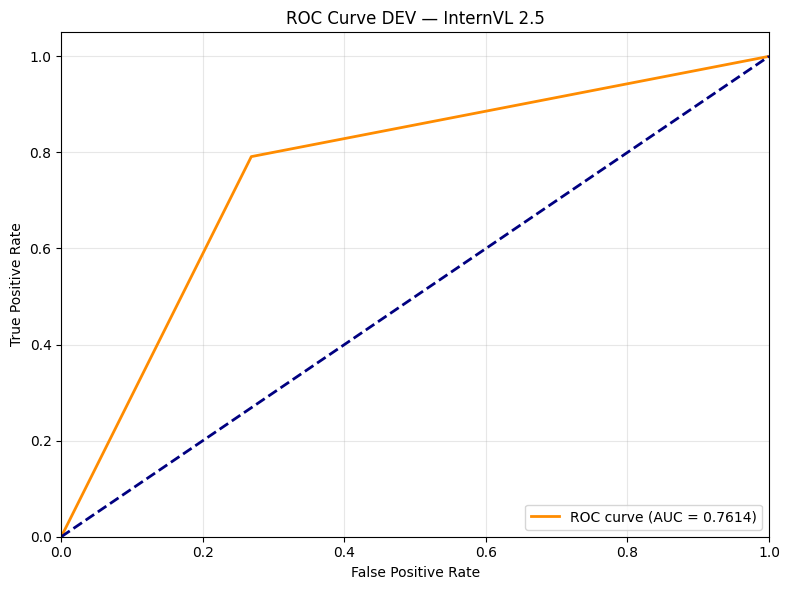

In [7]:
val_results = process_dataset(val_df, DATA_BASE_DIR, model, tokenizer, split_name="dev")

y_pred_labels = [label_map[r['classification']] for r in val_results]
y_true_labels = [label_map[r['true_label']] for r in val_results]
y_probs_dev   = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in val_results]

accuracy = accuracy_score(y_true_labels, y_pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true_labels, y_pred_labels, average='binary', zero_division=0
)

save_probs_json(val_df['id_EXIST'].values, y_probs_dev, 'dev', labels=val_df['label_int'].values)

print(f"\nMétricas en DEV:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall   : {recall:.4f}")
print(f"  F1-Score : {f1:.4f}")

fpr, tpr, _ = roc_curve(y_true_labels, y_probs_dev)
roc_auc = auc(fpr, tpr)
print(f"\nAUC (DEV): {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve DEV — InternVL 2.5')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluación en DEV con PyEvALL

In [8]:
dev_preds_for_pyevall = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in val_results
]
dev_preds_df   = pd.DataFrame(dev_preds_for_pyevall)
dev_preds_path = os.path.join(PREDICTIONS_DIR, 'dev_predictions_temp.json')
with open(dev_preds_path, 'w', encoding='utf-8') as f:
    f.write(dev_preds_df.to_json(orient='records'))

dev_gold = [
    {'test_case': 'EXIST2025', 'id': str(id_exist), 'value': label}
    for id_exist, label in zip(val_df['id_EXIST'].values, val_df[LABEL_COLUMN].values)
]
dev_gold_df   = pd.DataFrame(dev_gold)
dev_gold_path = os.path.join(PREDICTIONS_DIR, 'dev_gold_temp.json')
with open(dev_gold_path, 'w', encoding='utf-8') as f:
    f.write(dev_gold_df.to_json(orient='records'))

test_eval = PyEvALLEvaluation()
metrics   = [MetricFactory.Accuracy.value, MetricFactory.FMeasure.value]
report    = test_eval.evaluate(dev_preds_path, dev_gold_path, metrics)
print("\n=== Evaluación en DEV con PyEvALL ===")
report.print_report()

2026-03-06 00:27:56,572 - pyevall.evaluation - INFO -             evaluate() - Evaluating the following metrics ['Accuracy', 'FMeasure']


2026-03-06 00:27:56,606 - pyevall.metrics.metrics - INFO -             evaluate() - Executing accuracy evaluation method


2026-03-06 00:27:56,668 - pyevall.metrics.metrics - INFO -             evaluate() - Executing fmeasure evaluation method



=== Evaluación en DEV con PyEvALL ===
{
  "metrics": {
    "Accuracy": {
      "name": "Accuracy",
      "acronym": "Acc",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "average": 0.7672253258845437
        }],
        "average_per_test_case": 0.7672253258845437
      }
    },
    "FMeasure": {
      "name": "F-Measure",
      "acronym": "F1",
      "description": "Coming soon!",
      "status": "OK",
      "results": {
        "test_cases": [{
          "name": "EXIST2025",
          "classes": {
            "YES": 0.8025276461295419,
            "NO": 0.7165532879818595
          },
          "average": 0.7595404670557007
        }],
        "average_per_test_case": 0.7595404670557007
      }
    }
  },
  "files": {
    "dev_predictions_temp.json": {
      "name": "dev_predictions_temp.json",
      "status": "OK",
      "gold": false,
      "description": "Use parameter: report=\"embedd

## Inferencia en TEST y generación de predicciones finales

In [9]:
test_results = process_dataset(test_df, DATA_BASE_DIR, model, tokenizer, split_name="test")

y_probs_test = [r['confidence'] if r['classification'] == 'YES' else (1 - r['confidence']) for r in test_results]
test_preds   = [r['classification'] for r in test_results]

save_probs_json(test_df['id_EXIST'].values, y_probs_test, 'test')

print(f"\nPredicciones en TEST:")
print(f"  Total: {len(test_preds)}")
print(f"  YES  : {sum(1 for p in test_preds if p == 'YES')} ({100*sum(1 for p in test_preds if p == 'YES')/len(test_preds):.2f}%)")
print(f"  NO   : {sum(1 for p in test_preds if p == 'NO')} ({100*sum(1 for p in test_preds if p == 'NO')/len(test_preds):.2f}%)")

Inferencia test:   0%|          | 0/687 [00:00<?, ?it/s]


Predicciones en TEST:
  Total: 687
  YES  : 358 (52.11%)
  NO   : 329 (47.89%)


## Guardar predicciones en formato PyEvALL para TEST

In [10]:
test_preds_for_submission = [
    {'test_case': 'EXIST2025', 'id': str(r['id_EXIST']), 'value': r['classification']}
    for r in test_results
]
test_preds_df = pd.DataFrame(test_preds_for_submission)

output_filename = f"{GROUP_ID}_{MODEL_ID}.json"
output_path     = os.path.join(PREDICTIONS_DIR, output_filename)

with open(output_path, 'w', encoding='utf-8') as f:
    f.write(test_preds_df.to_json(orient='records'))

print(f"\nPredicciones guardadas en: {output_path}")


Predicciones guardadas en: ../predictions/BeingChillingWeWillWin_internvl25_26b.json
